In [ ]:
pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.9/471.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.6 which is incompatible.


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import List, TypedDict, Optional

In [ ]:
class AgentState(TypedDict):
  number1: int
  number2: int
  number3: int
  number4: int
  result1: Optional[int]
  result2: Optional[int]
  operator1: str
  operator2: str

In [29]:
def add_node(state: AgentState) -> AgentState:
  state['result1'] = state['number1'] + state['number2']
  return state

def sub_node(state: AgentState) -> AgentState:
  state['result1'] = state['number1'] - state['number2']
  return state

def decision_node(state: AgentState) -> AgentState:
  if state['operator1'] == "+":
    return "addition_operation1"
  else:
    return "subtraction_operation1"

def add_node1(state: AgentState) -> AgentState:
  state['result2'] = state['number3'] + state['number4']
  return state

def sub_node1(state: AgentState) -> AgentState:
  state['result2'] = state['number3'] - state['number4']
  return state

def decision_node1(state: AgentState) -> AgentState:
  if state['operator2'] == "+":
    return "addition_operation2"
  else:
    return "subtraction_operation2"

In [30]:
graph = StateGraph(AgentState)

graph.add_node("add nodes 1", add_node)
graph.add_node("sub nodes 1", sub_node)
graph.add_node("router1", lambda state:state)

graph.add_node("add nodes 2", add_node1)
graph.add_node("sub nodes 2", sub_node1)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router1")
graph.add_conditional_edges("router1", decision_node, {"addition_operation1": "add nodes 1", "subtraction_operation1": "sub nodes 1"})

graph.add_edge("add nodes 1", "router2")
graph.add_edge("sub nodes 1","router2")

graph.add_conditional_edges("router2", decision_node1, {"addition_operation2":"add nodes 2","subtraction_operation2": "sub nodes 2"})

graph.add_edge("add nodes 2", END)
graph.add_edge("sub nodes 2", END)


app = graph.compile()

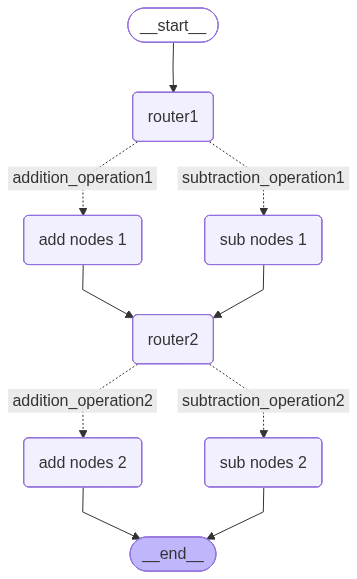

In [31]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
result = app.invoke({"number1": 10, "operator1": "-", "number2": 5, "number3": 7, "number4": 2, "operator2": "+"})
result

{'number1': 10,
 'number2': 5,
 'number3': 7,
 'number4': 2,
 'result1': 5,
 'result2': 9,
 'operator1': '-',
 'operator2': '+'}